# Bibliotekos

In [18]:
from pathlib import Path
import xarray as xr
import numpy as np
import glob
import os
import pandas as pd

# Direktorijos nustatymai

In [42]:
base_path = Path(os.getcwd())
repo_root = base_path.parents[2]
FOLDER = f'{repo_root}\\..\\sentinel_data\\S5P_Cloud'
nc_files = [f for f in os.listdir(FOLDER) if f.endswith('.nc')]
first_file = os.path.join(FOLDER, nc_files[3])
ds = xr.open_dataset(first_file)

# Duomenų paketo nuskaitymas

In [43]:
print("=== DIMENSIONS ===")
for dim, size in ds.sizes.items():
    print(f"  {dim:10s}: {size:,}")

print("\n=== COORDINATES ===")
for name, coord in ds.coords.items():
    if name == 'time':
        print(f"  {name:10s}: {coord.values[0]} → {coord.values[-1]}  ({len(coord):,} steps)")
    else:
        print(f"  {name:10s}: {float(coord.min()):.4f} → {float(coord.max()):.4f}")

print("\n=== VARIABLES ===")
for name, var in ds.data_vars.items():
    print(f"  {name}")
    print(f"    shape  : {var.shape}")
    print(f"    dtype  : {var.dtype}")
    print(f"    dims   : {var.dims}")

print(f"\n=== SIZE ===")
print(f"  In-memory (uncompressed): {ds.nbytes / 1e9:.2f} GB")
print(f"  On-disk:                  {os.path.getsize(first_file) / 1e9:.2f} GB")
print(f"  Compression ratio:        {ds.nbytes / os.path.getsize(first_file):.1f}x")

=== DIMENSIONS ===
  time      : 560
  lon       : 593
  lat       : 255

=== COORDINATES ===
  time      : 2020-10-21T09:32:28.000000000 → 2021-07-27T10:50:39.000000000  (560 steps)
  lon       : 20.9465 → 26.8665
  lat       : 53.9063 → 56.4463

=== VARIABLES ===
  cloud_fraction
    shape  : (560, 593, 255)
    dtype  : float32
    dims   : ('time', 'lon', 'lat')
  cloud_top_pressure
    shape  : (560, 593, 255)
    dtype  : float32
    dims   : ('time', 'lon', 'lat')
  cloud_top_height
    shape  : (560, 593, 255)
    dtype  : float32
    dims   : ('time', 'lon', 'lat')
  cloud_base_pressure
    shape  : (560, 593, 255)
    dtype  : float32
    dims   : ('time', 'lon', 'lat')
  cloud_base_height
    shape  : (560, 593, 255)
    dtype  : float32
    dims   : ('time', 'lon', 'lat')
  cloud_optical_depth
    shape  : (560, 593, 255)
    dtype  : float32
    dims   : ('time', 'lon', 'lat')

=== SIZE ===
  In-memory (uncompressed): 2.03 GB
  On-disk:                  0.49 GB
  Compressi

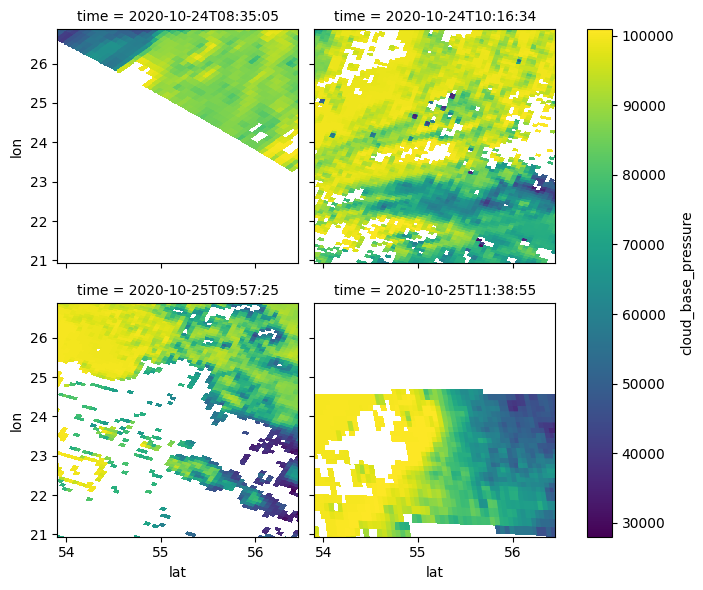

In [45]:
ds['cloud_base_pressure'].isel(time=slice(6, 10)).plot(col='time', col_wrap=2, cmap='viridis')

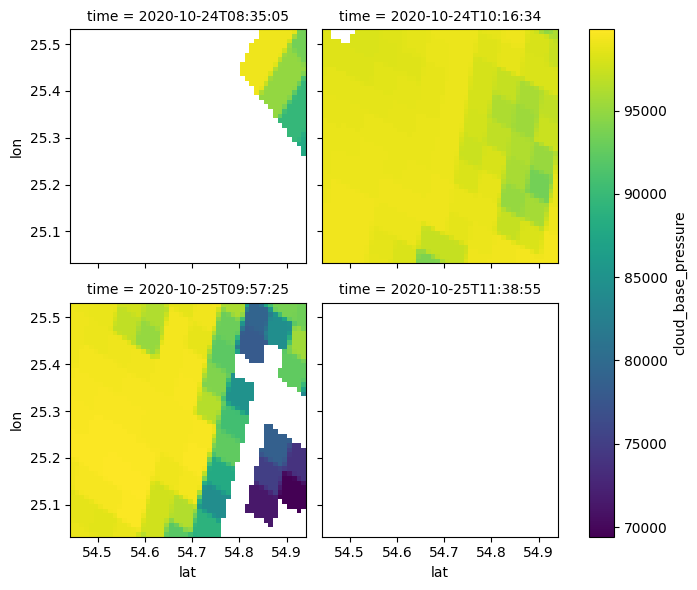

In [46]:
vilnius_lon, vilnius_lat = 25.2797, 54.6872
ds_box = ds.sel(
                lon=slice(vilnius_lon - 0.25, vilnius_lon + 0.25),
                lat=slice(vilnius_lat - 0.25, vilnius_lat + 0.25))

ds_box['cloud_base_pressure'].isel(time=slice(6, 10)).plot(col='time', col_wrap=2, cmap='viridis')

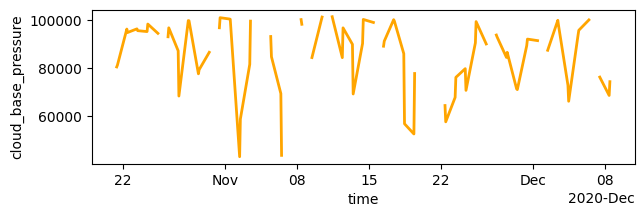

In [75]:
ds_regional = ds_box.mean(dim=['lat', 'lon'])
ds_regional['cloud_base_pressure'][:100].plot(
    figsize=(7, 2), 
    color="orange", 
    linewidth=2
)

<Axes: xlabel='time'>

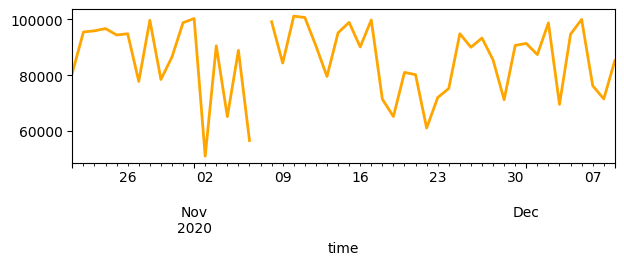

In [77]:
df = ds_regional.to_dataframe()
df_new = df.groupby(df.index.floor('D')).mean().reset_index()
df_new.set_index('time')['cloud_base_pressure'][:50].plot(
    figsize=(7, 2), 
    color="orange", 
    linewidth=2
)

In [64]:
not_null_mask = ds['SO2_column_number_density'].notnull()

valid_fraction = not_null_mask.mean(dim=['lon', 'lat'])

valid_frames = valid_fraction.where(valid_fraction >= 0.85, drop=True)

print(f"Iš viso kadrų: {len(ds.time)}")
print(f"Kadrų su >50% duomenų: {len(valid_frames.time)}")
print(valid_frames.time.values)

Iš viso kadrų: 355
Kadrų su >50% duomenų: 26
['2021-04-18T10:23:22.000000000' '2021-05-10T10:12:33.000000000'
 '2021-05-11T09:53:35.000000000' '2021-05-11T11:35:06.000000000'
 '2021-05-12T09:34:37.000000000' '2021-06-14T09:16:41.000000000'
 '2021-06-16T10:20:07.000000000' '2021-06-17T10:01:05.000000000'
 '2021-06-17T11:42:35.000000000' '2021-06-18T09:42:02.000000000'
 '2021-06-18T11:23:32.000000000' '2021-06-19T09:23:00.000000000'
 '2021-06-19T11:04:30.000000000' '2021-06-20T09:03:57.000000000'
 '2021-06-20T10:45:28.000000000' '2021-06-21T10:26:25.000000000'
 '2021-06-23T09:48:18.000000000' '2021-06-29T09:35:35.000000000'
 '2021-06-30T09:16:31.000000000' '2021-06-30T10:58:01.000000000'
 '2021-07-15T09:35:07.000000000' '2021-07-16T09:16:03.000000000'
 '2021-07-25T09:47:19.000000000' '2021-09-09T10:21:33.000000000'
 '2021-09-10T10:02:25.000000000' '2021-09-26T10:00:41.000000000']


In [79]:
height = ds.sizes['lat']
width = ds.sizes['lon']

print(f"Paveikslėlio rezoliucija: {height}x{width} px")

Paveikslėlio rezoliucija: 255x593 px


# Kiti pasižiūrėjimai

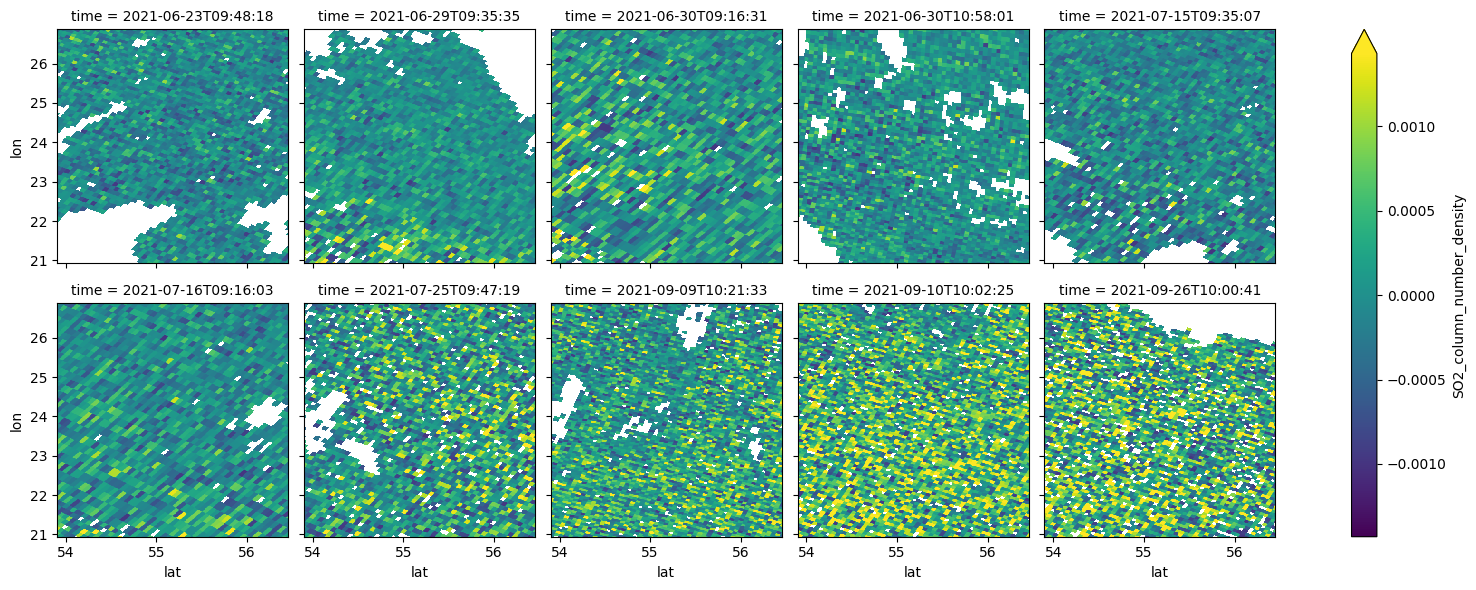

In [67]:
ds_valid = ds['SO2_column_number_density'].sel(time=valid_frames.time)

ds_valid.isel(time=slice(-10, None)).plot(
    col='time', 
    col_wrap=5,
    cmap='viridis',
    robust=True
)

In [106]:
mask = ~ds['cloud_base_pressure'].isnull().all(dim=['lat', 'lon'])
ds_filtered = ds.sel(time=mask)
print(f"Original time steps: {ds.time.size}")
print(f"Time steps with data: {ds_filtered.time.size}")

Original time steps: 481
Time steps with data: 479


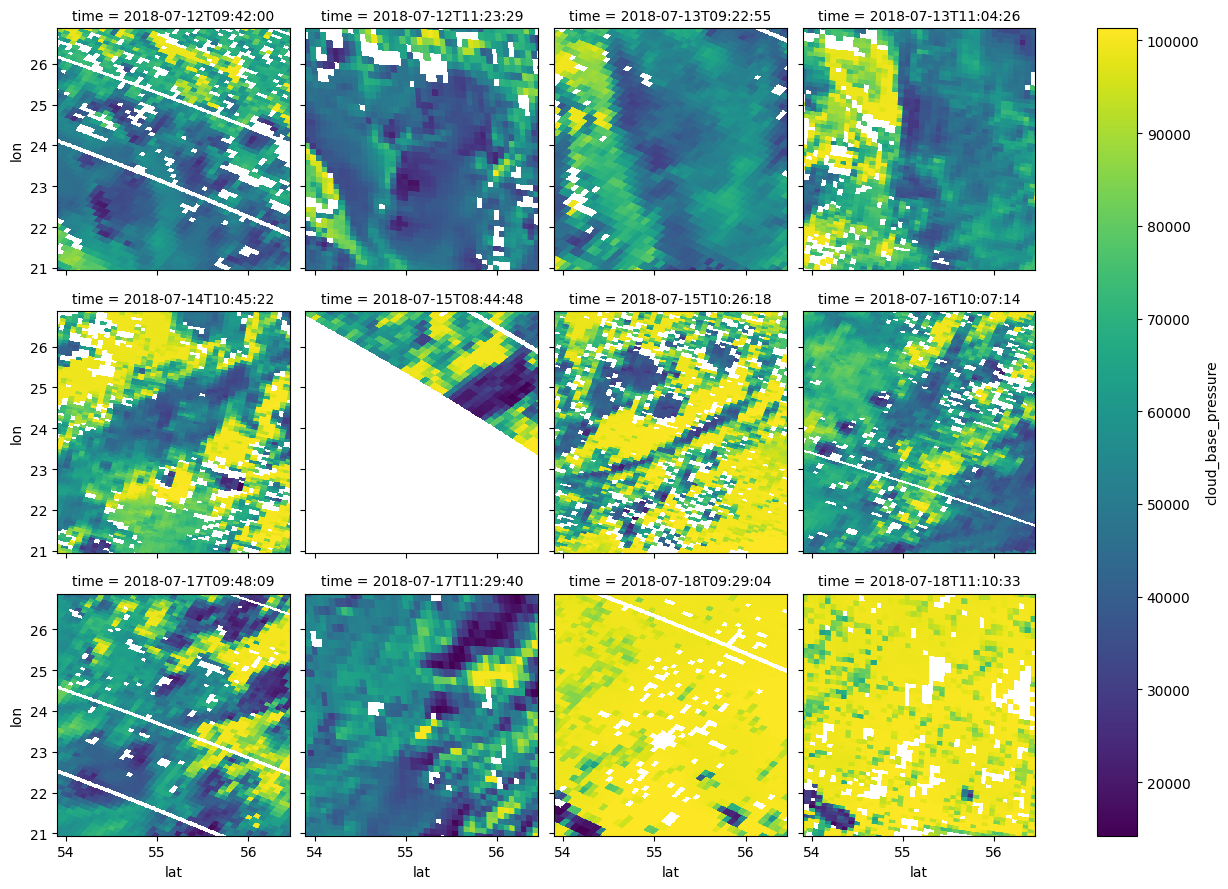

In [107]:
ds_filtered['cloud_base_pressure'].isel(time=slice(0, 12)).plot(col='time', col_wrap=4, cmap='viridis')

In [ ]:
daily_resampler = ds_filtered.resample(time='1D')
ds_daily = daily_resampler.mean()
print(f"Frames before: {ds_filtered.time.size}")
print(f"Days after:    {ds_daily.time.size}")

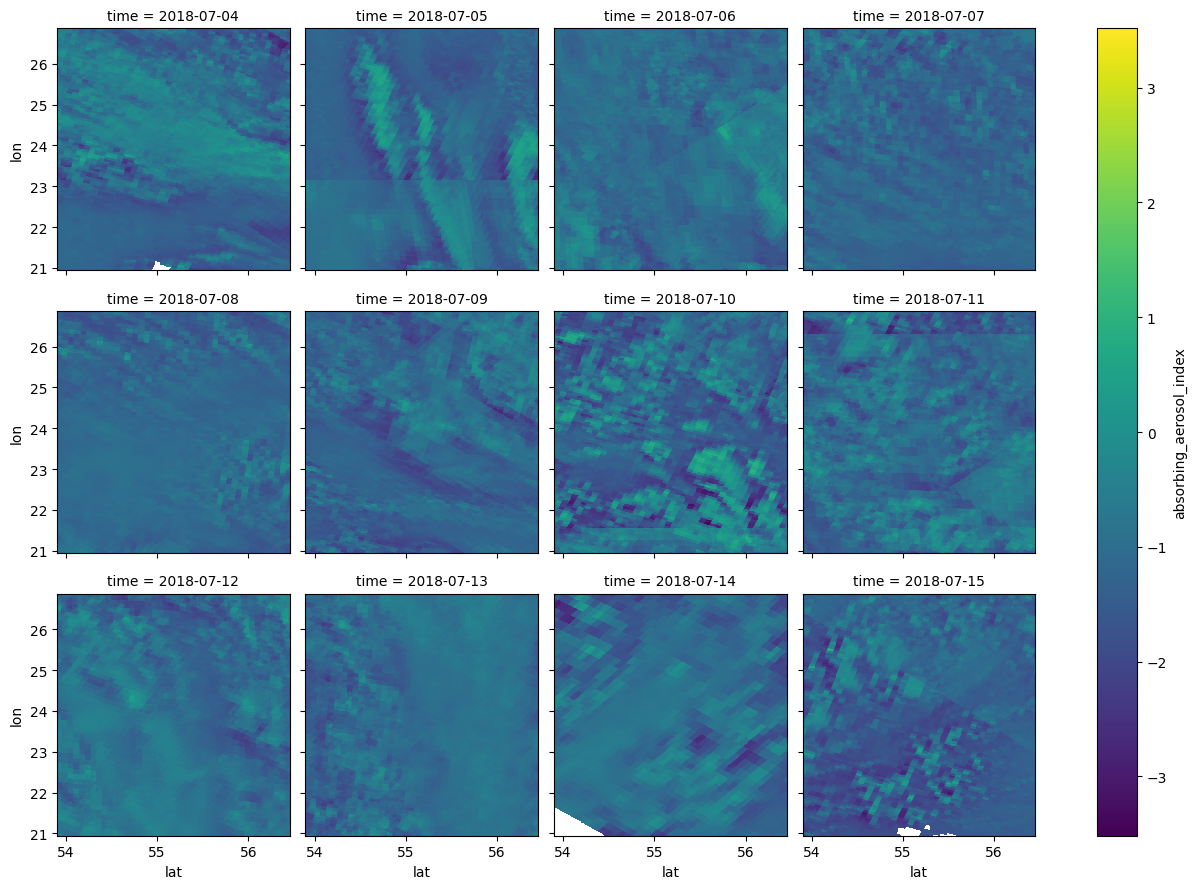

In [ ]:
ds_daily['cloud_base_pressure'].isel(time=slice(0, 12)).plot(col='time', col_wrap=4, cmap='viridis')

In [ ]:
ds_compressed = ds_daily.coarsen(lat=15, lon=30, boundary='trim').mean()

In [ ]:
ds_compressed['absorbing_aerosol_index'].isel(time=slice(0, 12)).plot(col='time', col_wrap=4, cmap='viridis')

In [88]:
vilnius_lon, vilnius_lat = 25.2797, 54.6872
ds_vilnius = ds_compressed.sel(lon=vilnius_lon, lat=vilnius_lat, method='nearest')
print(ds_vilnius)

<xarray.Dataset> Size: 3kB
Dimensions:                  (time: 280)
Coordinates:
  * time                     (time) datetime64[ns] 2kB 2018-07-04 ... 2019-04-09
    lon                      float64 8B 25.29
    lat                      float64 8B 54.73
Data variables:
    absorbing_aerosol_index  (time) float32 1kB -0.6793 0.2053 ... -0.3555
Attributes: (12/19)
    date_range:               [1530662400000 1647734400000]
    description:              <h3 id="offll3_aer_ai">OFFL/L3_AER_AI</h3><p>Th...
    keywords:                 ['aai', 'aerosol', 'air_quality', 'copernicus',...
    period:                   0
    product_tags:             ['tropomi', 'aerosol', 'aai', 'uvai', 'pollutio...
    provider:                 European Union/ESA/Copernicus
    ...                       ...
    visualization_0_bands:    absorbing_aerosol_index
    visualization_0_max:      1.5
    visualization_0_min:      -1.0
    visualization_0_name:     RGB
    visualization_0_palette:  black,blue,purple,c

In [98]:
ds_vilnius.to_dataframe().head()

,absorbing_aerosol_index,lon,lat
time,,,
2018-07-04,-0.679349,25.291513,54.726301
2018-07-05,0.205332,25.291513,54.726301
2018-07-06,-0.872028,25.291513,54.726301
2018-07-07,-1.232945,25.291513,54.726301
2018-07-08,-1.270795,25.291513,54.726301


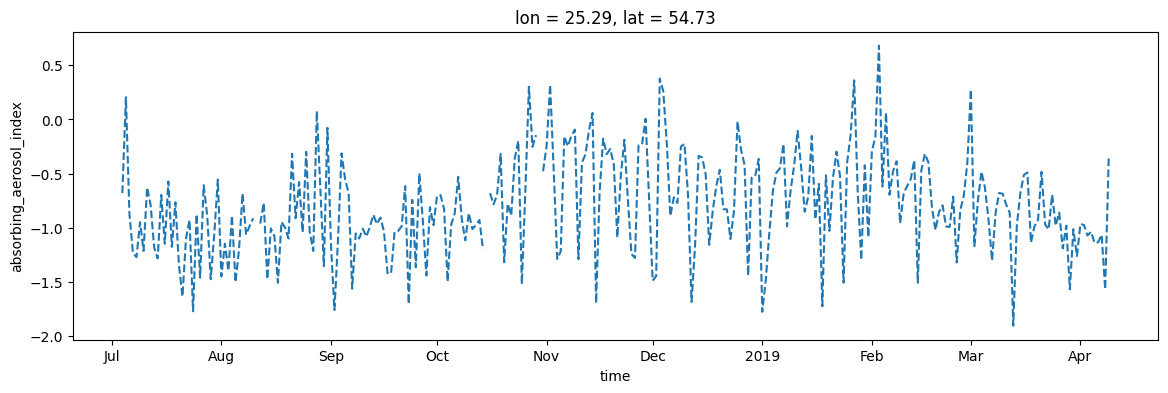

In [96]:
ds_vilnius['absorbing_aerosol_index'].plot(figsize=(14, 4), linestyle='--')

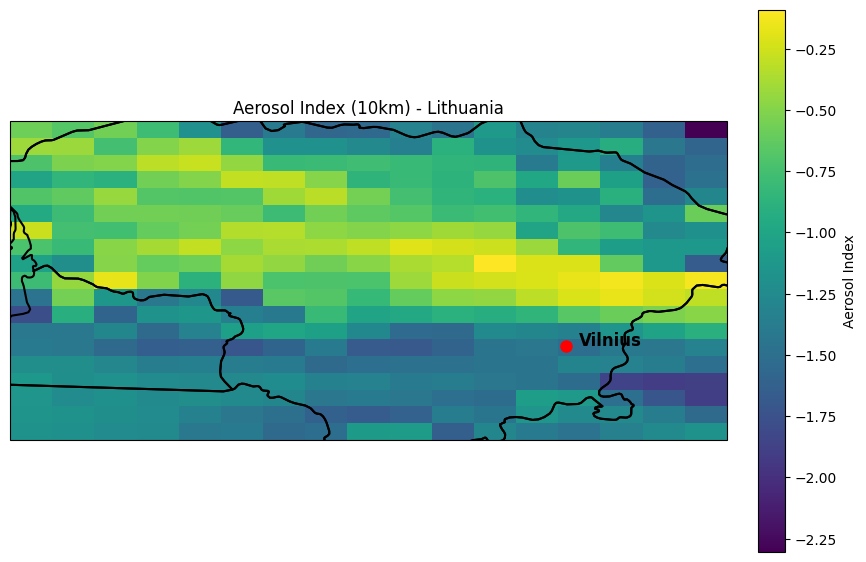

In [99]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

vilnius_lon, vilnius_lat = 25.2797, 54.6872
sample_frame = ds_compressed['absorbing_aerosol_index'].isel(time=0)

plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

countries = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_0_countries', scale='10m', facecolor='none'
)
ax.add_feature(countries, edgecolor='black', linewidth=1.5, zorder=3)

extent = [
    sample_frame.lon.min().item(), sample_frame.lon.max().item(),
    sample_frame.lat.min().item(), sample_frame.lat.max().item()
]

im = ax.imshow(
    sample_frame.values,
    extent=extent,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    origin='lower',
    zorder=1
)

ax.plot(vilnius_lon, vilnius_lat, 'ro', markersize=8, transform=ccrs.PlateCarree(), zorder=5)
ax.text(vilnius_lon + 0.1, vilnius_lat, 'Vilnius', transform=ccrs.PlateCarree(), 
        fontsize=12, fontweight='bold', zorder=5)

plt.colorbar(im, ax=ax, label='Aerosol Index', fraction=0.035, pad=0.04)

plt.title(f"Aerosol Index (10km) - Lithuania")
plt.show()

# Praleistos reikšmės

In [7]:
df_s5p = pd.read_csv("Sentinel_5p_data.csv")

In [8]:
df_s5p.iloc[1100:1110]

,Unnamed: 0,time,absorbing_aerosol_index,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth,NO2_column_number_density,tropospheric_NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,O3_column_number_density,O3_effective_temperature,CO_column_number_density,H2O_column_number_density
1100,1100,2021-07-02,-1.394758,0.880325,45653.445,6588.5884,52063.050,5589.7190,10.935252,0.000075,0.000014,0.000066,0.000153,16676.727,0.145045,236.07013,0.027926,2067.3260
1101,1101,2021-07-03,-0.569932,0.486333,74264.720,2661.8748,83348.234,1707.8862,9.067339,0.000084,0.000013,0.000071,0.000222,16678.275,0.145141,235.15839,0.028020,1621.0469
1102,1102,2021-07-04,-0.562013,0.721356,72006.340,2926.2922,81052.360,1939.0280,10.645254,0.000079,0.000012,0.000067,0.000195,16679.441,0.144736,233.61784,0.027545,2036.9648
1103,1103,2021-07-05,-1.076837,0.686987,50756.227,5658.3800,57873.633,4665.7190,6.284062,0.000088,0.000022,0.000065,0.000192,16680.057,0.142288,235.41626,0.028177,2615.5996
1104,1104,2021-07-06,-0.982162,0.994396,44569.920,6438.4180,51088.656,5438.4180,81.470116,0.000082,NaN,0.000057,0.000172,16683.018,0.143822,235.15390,NaN,NaN
1105,1105,2021-07-07,-0.467726,0.352363,73058.590,2874.5466,81142.090,2008.5764,5.651166,0.000081,0.000021,0.000058,0.000198,14419.268,0.134793,235.55550,0.030838,2149.8303
1106,1106,2021-07-08,-1.461856,0.449523,72145.860,2852.9443,80538.660,1953.0717,8.213847,0.000077,0.000019,0.000058,0.000150,13053.426,0.132513,235.31226,0.028903,2316.0780
1107,1107,2021-07-09,-0.625181,0.225482,83434.300,1650.9976,91910.640,845.9197,5.326018,0.000082,0.000022,0.000060,0.000194,14419.514,0.134487,236.37263,0.028706,1892.9233
1108,1108,2021-07-10,-0.552420,0.191991,80694.695,1919.6228,89557.670,1058.6731,4.704025,0.000079,0.000018,0.000061,0.000189,14426.717,0.133291,236.43347,0.029926,1178.6355
1109,1109,2021-07-11,-0.656333,0.198883,80038.530,1978.4728,88264.640,1167.4016,3.796909,0.000085,0.000028,0.000059,0.000193,14418.874,0.133486,235.95448,0.030274,1982.3542


In [9]:
full_period = df_s5p[df_s5p['time'] > '2019-02-08']
full_period

,Unnamed: 0,time,absorbing_aerosol_index,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth,NO2_column_number_density,tropospheric_NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,O3_column_number_density,O3_effective_temperature,CO_column_number_density,H2O_column_number_density
226,226,2019-02-09,-0.813143,0.335364,22859.365,10548.8350,26629.980,9601.9890,9.753179,0.000236,NaN,0.000025,0.000180,14415.494,NaN,NaN,NaN,NaN
227,227,2019-02-10,-0.578261,0.409869,54418.750,4567.6840,62068.380,3610.4258,5.461665,0.000102,NaN,0.000025,0.000179,19217.715,0.197548,218.42644,0.034966,642.82025
228,228,2019-02-11,-0.556664,0.705265,38632.210,7010.0880,44437.890,6045.2812,13.781952,0.000244,NaN,0.000026,0.000158,19192.172,0.189422,219.16690,NaN,NaN
229,229,2019-02-12,-0.572631,0.582546,62986.580,3587.1768,70985.016,2703.9760,5.882026,0.000095,NaN,0.000027,0.000154,22064.297,0.199671,219.19342,0.034909,381.00732
230,230,2019-02-13,-0.376510,0.789514,56834.344,4377.9277,64736.220,3418.9470,9.986307,0.000073,NaN,0.000023,0.000133,17957.320,0.167463,217.76395,0.034544,346.62018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2809,2809,2026-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.184355,221.35965,0.030829,589.50740
2810,2810,2026-03-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.163973,221.73358,0.037622,739.04004
2811,2811,2026-03-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.160919,221.86159,0.035537,389.88342
2812,2812,2026-03-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.032693,491.09270


In [10]:
(full_period.isnull().sum() / 2589) * 100

Unnamed: 0                                  0.000000
time                                        0.000000
absorbing_aerosol_index                     0.733874
cloud_fraction                              7.493241
cloud_top_pressure                         11.548861
cloud_top_height                           11.548861
cloud_base_pressure                        11.548861
cloud_base_height                          11.548861
cloud_optical_depth                        11.548861
NO2_column_number_density                   7.415991
tropospheric_NO2_column_number_density     42.912321
stratospheric_NO2_column_number_density     7.415991
NO2_slant_column_number_density             7.415991
tropopause_pressure                         7.415991
O3_column_number_density                    0.772499
O3_effective_temperature                    0.772499
CO_column_number_density                   17.651603
H2O_column_number_density                  10.853611
dtype: float64

<Axes: xlabel='time'>

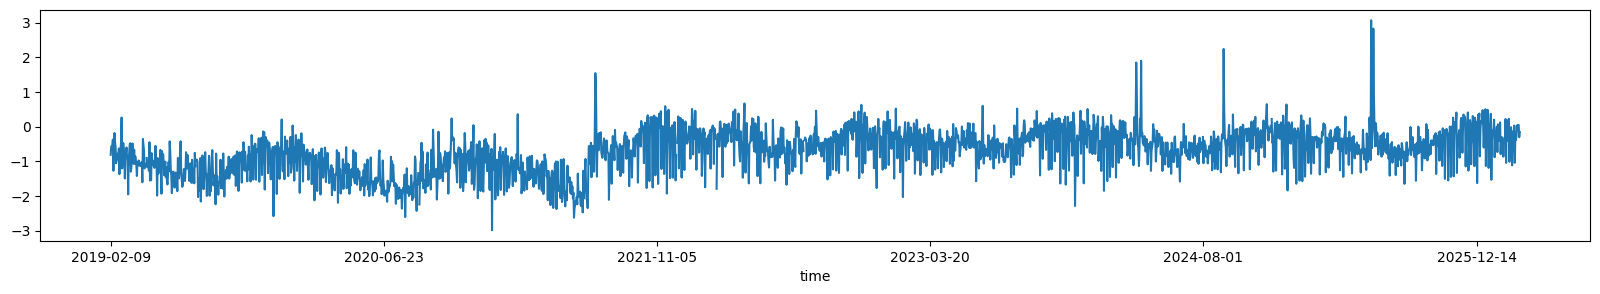

In [17]:
full_period.set_index('time').absorbing_aerosol_index.plot(figsize=(20,3))